# 02 – Data Cleaning & Integration
## CIP_FS26_203 | Weather & Electricity Prices in Switzerland

This notebook cleans and integrates the three raw datasets:
- **Open-Meteo** – Weather data (Zurich, Basel, Geneva, Lugano)
- **ENTSO-E** – Day-ahead electricity prices (CH, EUR/MWh)
- **Swissgrid** – National electricity load data (MW)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Display settings ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print("All packages loaded successfully!")

All packages loaded successfully!


## 1. ENTSO-E – Day-Ahead Prices Cleaning

### 1.1 Basic inspection of fetched API data

In [5]:
# --- Load raw ENTSO-E prices ---
df_prices = pd.read_csv("../data/raw/prices/entsoe_prices_raw.csv", parse_dates=["date"])

# --- Basic inspection ---
print(f"Shape: {df_prices.shape}")
print(f"\nData types:\n{df_prices.dtypes}")
print(f"\nDate range: {df_prices['date'].min()} to {df_prices['date'].max()}")
print(f"\nMissing values:\n{df_prices.isnull().sum()}")
print(f"\nBasic statistics:\n{df_prices['price_eur_mwh'].describe()}")

# --- Check for missing dates (gaps in time series) ---
full_range = pd.date_range(start=df_prices["date"].min(),
                           end=df_prices["date"].max(),
                           freq="D")
missing_dates = full_range.difference(df_prices["date"])
print(f"Missing dates: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(missing_dates)

Shape: (4017, 2)

Data types:
date             datetime64[us]
price_eur_mwh           float64
dtype: object

Date range: 2015-01-01 00:00:00 to 2025-12-30 00:00:00

Missing values:
date             0
price_eur_mwh    0
dtype: int64

Basic statistics:
count   4017.00
mean      84.79
std       83.82
min      -12.67
25%       37.59
50%       55.09
75%       98.42
max      724.87
Name: price_eur_mwh, dtype: float64
Missing dates: 0


**Inspection findings:**
The ENTSO-E dataset contains 4,017 daily observations from 2015-01-01 to 2025-12-30,
with no missing values in either column. The date column is correctly typed as
datetime64 and the price column as float64. No date gaps were detected, confirming
a complete and continuous daily time series.

### 1.2 Graphical inspection of fetched API data

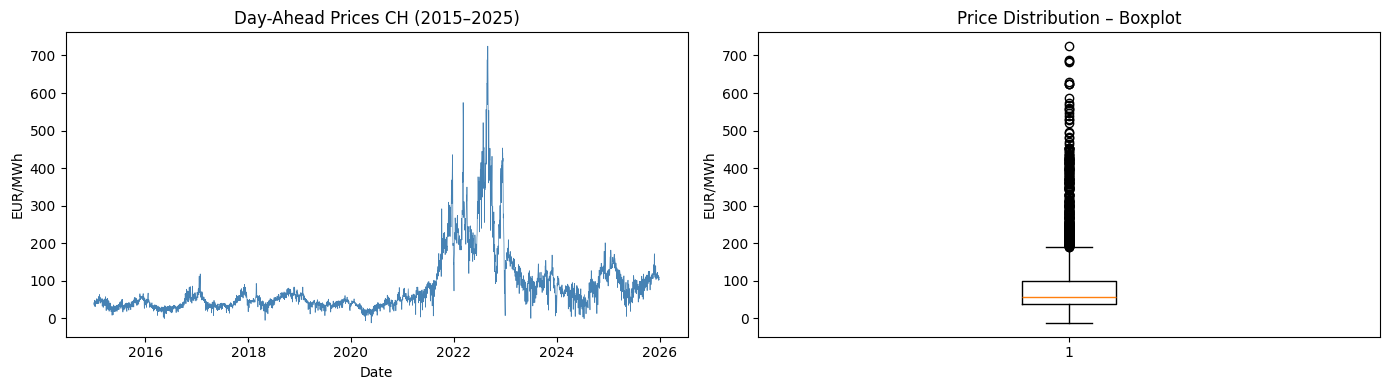

Figure saved.


In [9]:
# --- Visualise price distribution to identify outliers ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series
axes[0].plot(df_prices["date"], df_prices["price_eur_mwh"], linewidth=0.5, color="steelblue")
axes[0].set_title("Day-Ahead Prices CH (2015–2025)")
axes[0].set_ylabel("EUR/MWh")
axes[0].set_xlabel("Date")

# Boxplot
axes[1].boxplot(df_prices["price_eur_mwh"].dropna(), vert=True)
axes[1].set_title("Price Distribution – Boxplot")
axes[1].set_ylabel("EUR/MWh")

plt.tight_layout()
plt.savefig("../figures/entsoe_prices_overview.png", dpi=150)
plt.show()
print("Figure saved.")

**Visualisation findings:**
The time series reveals a stable price regime from 2015 to 2020 (mean ~40–60 EUR/MWh),
followed by an extreme spike during the 2021–2023 energy crisis (peak: 724.87 EUR/MWh).
The boxplot confirms a heavily right-skewed distribution with numerous outliers above
the IQR upper bound. A negative minimum (-12.67 EUR/MWh) reflects occasional periods
of excess renewable energy supply. These extreme values are real market events, not
data errors, and will be retained for analysis.

### 1.3 Outlier Analysis of fetched API data

In [6]:
# --- Outlier analysis using IQR method ---
Q1 = df_prices["price_eur_mwh"].quantile(0.25)
Q3 = df_prices["price_eur_mwh"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_prices[
    (df_prices["price_eur_mwh"] < lower) |
    (df_prices["price_eur_mwh"] > upper)
]

print(f"IQR bounds: [{lower:.2f}, {upper:.2f}] EUR/MWh")
print(f"Outliers detected: {len(outliers)} rows ({len(outliers)/len(df_prices)*100:.1f}%)")
print(f"Outlier date range: {outliers['date'].min().date()} to {outliers['date'].max().date()}")
print(f"\nOutlier price statistics:\n{outliers['price_eur_mwh'].describe()}")

IQR bounds: [-53.65, 189.66] EUR/MWh
Outliers detected: 370 rows (9.2%)
Outlier date range: 2021-10-07 to 2024-12-11

Outlier price statistics:
count   370.00
mean    301.89
std     104.97
min     190.13
25%     220.92
50%     265.73
75%     366.70
max     724.87
Name: price_eur_mwh, dtype: float64


**Outlier findings & decision:**
The IQR method (bounds: [-53.65, 189.66] EUR/MWh) identifies 370 rows (9.2%) as
statistical outliers. These observations span from 2021-10-07 to 2024-12-11, with
a mean of 301.89 EUR/MWh and a peak of 724.87 EUR/MWh. This period corresponds
directly to the European energy crisis triggered by post-COVID demand recovery and
the disruption of Russian gas supplies following the outbreak of the Russia-Ukraine
war in February 2022. These are documented real-world market events – not
measurement errors or data quality issues. Removing or capping these values would
distort the analysis of RQ2 and RQ3, as the crisis period represents the most
informative signal for understanding the relationship between weather conditions
and electricity prices under stress. Outliers are therefore retained in full. **Decision -> Retain outliers.**

### 1.4 Data Type & Range Validation

In [7]:
# --- Validate data types ---
assert df_prices["date"].dtype == "datetime64[us]", "ERROR: date column is not datetime"
assert df_prices["price_eur_mwh"].dtype == "float64", "ERROR: price column is not float64"
print("Data types: OK")

# --- Validate value ranges ---
# Prices below -500 EUR/MWh or above 5000 EUR/MWh are physically implausible
price_min_threshold = -500
price_max_threshold = 5000

invalid_range = df_prices[
    (df_prices["price_eur_mwh"] < price_min_threshold) |
    (df_prices["price_eur_mwh"] > price_max_threshold)
]
print(f"Values outside plausible range [{price_min_threshold}, {price_max_threshold}]: {len(invalid_range)} rows")

# --- Validate date range ---
assert df_prices["date"].min() == pd.Timestamp("2015-01-01"), "ERROR: Start date mismatch"
assert df_prices["date"].max() >= pd.Timestamp("2025-12-30"), "ERROR: End date mismatch"
print("Date range: OK")

print("\nAll validation checks passed.")

Data types: OK
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Values outside plausible range [-500, 5000]: 0 rows
Date range: OK

All validation checks passed.


**Validation findings:**
All data type and range checks passed without errors. The date column is correctly
typed as datetime64 and the price column as float64. No physically implausible
price values were detected outside the threshold of [-500, 5000] EUR/MWh. The
dataset covers the full intended period from 2015-01-01 to 2025-12-30.

### 1.5 Save Cleaned ENTSO-E Data

In [8]:
# --- Save cleaned ENTSO-E prices to processed folder ---
output_path = "../data/processed/entsoe_prices_clean.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_prices_clean = df_prices.copy()
df_prices_clean.to_csv(output_path, index=False)
print(f"Saved: {output_path} ({len(df_prices_clean)} rows, {df_prices_clean.shape[1]} columns)")

Saved: ../data/processed/entsoe_prices_clean.csv (4017 rows, 2 columns)


**Summary – ENTSO-E Cleaning:**
The ENTSO-E dataset required minimal cleaning: no missing values, no date gaps,
and correct data types were confirmed. 370 statistical outliers (9.2%) corresponding
to the 2021–2023 energy crisis were identified and deliberately retained. The cleaned
dataset (4,017 rows) has been saved to `data/processed/entsoe_prices_clean.csv`
and is ready for integration with the weather and load datasets.

## 2. Open-Meteo – Weather Data Cleaning (Zurich, Basel, Geneva, Lugano)

tbd Joel/Aurora

## 3. Swissgrid – National Load Data Cleaning (CH)

tbd Joel/Aurora